# Reference Resolution Dev Notebook

In [1]:
import random
import torch
import io
import pyarrow as pa
import os
import copy
import pytorch_lightning as pl
from sacred import Experiment
from PIL import Image
from tqdm.auto import tqdm
import numpy as np
import skimage.io as skio
import matplotlib.pyplot as plt
# from PIL import Image as PImage # pillow
from refer import REFER



from torch.optim import AdamW

from meter.transforms import keys_to_transforms
from meter.config import ex
from meter.modules import METERTransformerSS
from meter.datamodules.multitask_datamodule import MTDataModule
from meter.datasets.base_dataset import BaseDataset

/home/claytonfields/anaconda3/envs/meter/lib/python3.7/site-packages/skimage/io/manage_plugins.py:23: UserWarning: Your installed pillow version is < 8.1.2. Several security issues (CVE-2021-27921, CVE-2021-25290, CVE-2021-25291, CVE-2021-25293, and more) have been fixed in pillow 8.1.2 or higher. We recommend to upgrade this library.
  from .collection import imread_collection_wrapper


## RefCOCO Data

### Utility Functions

In [2]:
def get_bounded_subimage(img_id, ann_id, xs=224,ys=224, show=False):
    bbox = refer.Anns[ann_id]['bbox']
    bbox = [int(b) for b in bbox]
    img = refer.Imgs[img_id]
    I = skio.imread(os.path.join(refer.IMAGE_DIR, img['file_name']))
    sub = I[bbox[1]:bbox[1]+bbox[3],bbox[0]:bbox[0]+bbox[2]]
    if show:
        plt.figure()
        ax = plt.gca()
        ax.imshow(sub)
        plt.show()
    if len(sub) == 0: return None
    pim = Image.fromarray(sub)
    pim2 = pim.resize((xs,ys), Image.ANTIALIAS)
    img = np.array(pim2)
    if len(img.shape) < 3: return None
    img = img.reshape((1, img.shape[0], img.shape[1], img.shape[2]))
    return img

def get_img_features(model, img):
    if img is None: return None
    img = preprocess_input(img)
    yhat = model.predict(img)
    return yhat

def compute_posfeats(img_id, ann_id,):
    img = refer.Imgs[img_id]
    bb = refer.Anns[ann_id]['bbox']
    fname = os.path.join(refer.IMAGE_DIR, img['file_name'])
    if not os.path.isfile(fname): return None
    img = io.imread(fname)
    
    if len(img.shape) < 3: return None
    ih, iw, _ = img.shape
    x,y,w,h = bb
    # x1, relative
    x1r = x / iw
    # y1, relative
    y1r = y / ih
    # x2, relative
    x2r = (x+w) / iw
    # y2, relative
    y2r = (y+h) / ih
    # area
    area = (w*h) / (iw*ih)
    # ratio image sides (= orientation)
    ratio = iw / ih
    # distance from center (normalised)
    cx = iw / 2
    cy = ih / 2
    bcx = x + w / 2
    bcy = y + h / 2
    distance = np.sqrt((bcx-cx)**2 + (bcy-cy)**2) / np.sqrt(cx**2+cy**2)
    # done!
    return np.array([x1r,y1r,x2r,y2r,area,ratio,distance]).reshape(1,7)

### Import and Explore Data

In [3]:
data_root = '/home/claytonfields/nlp/code/data/coco'  # contains refclef, refcoco, refcoco+, refcocog and images
dataset = 'refcoco' 
splitBy = 'unc'
refer = REFER(data_root, dataset, splitBy)

loading dataset refcoco into memory...
testing
creating index...
index created.
DONE (t=9.84s)


In [4]:
# print stats about the given dataset
print ('dataset [%s_%s] contains: ' % (dataset, splitBy))
ref_ids = refer.getRefIds()
image_ids = refer.getImgIds()
print ('%s expressions for %s refs in %s images.' % (len(refer.Sents), len(ref_ids), len(image_ids)))

print ('\nAmong them:')
if dataset == 'refclef':
    if splitBy == 'unc':
        splits = ['train', 'val', 'testA', 'testB', 'testC']
    else:
        splits = ['train', 'val', 'test']
elif dataset == 'refcoco':
    splits = ['train', 'val', 'test']
elif dataset == 'refcoco+':
    splits = ['train', 'val', 'test']
elif dataset == 'refcocog':
    splits = ['train', 'val']  # we don't have test split for refcocog right now.
    
for split in splits:
    ref_ids = refer.getRefIds(split=split)
    print ('%s refs are in split [%s].' % (len(ref_ids), split))

dataset [refcoco_unc] contains: 
142210 expressions for 50000 refs in 19994 images.

Among them:
42404 refs are in split [train].
3811 refs are in split [val].
3785 refs are in split [test].


In [5]:
# first, get all of the training data
train_ids = refer.getRefIds(split='train')
# train_ids = train_ids[]
train_ids[:5]

[0, 1, 2, 3, 4]

In [6]:
words = []
for ref_id in train_ids:
    ref = refer.Refs[ref_id]
    img_id = ref['image_id']
    ann_id = ref['ann_id']
    for sent in ref['sentences']:
        for word in sent['tokens']:
            if  word not in words:
                words.append(word)
len(words)

9364

In [7]:
ref_ids = refer.getRefIds()
print(len(ref_ids))
ref_id = 0 # pick a random ref_id
ref = refer.Refs[ref_id]

ref # a dictionary with all of the needed info for a referring expression+image

50000


{'sent_ids': [0, 1, 2],
 'file_name': 'COCO_train2014_000000581857_16.jpg',
 'ann_id': 1719310,
 'ref_id': 0,
 'image_id': 581857,
 'split': 'train',
 'sentences': [{'tokens': ['the', 'lady', 'with', 'the', 'blue', 'shirt'],
   'raw': 'THE LADY WITH THE BLUE SHIRT',
   'sent_id': 0,
   'sent': 'the lady with the blue shirt'},
  {'tokens': ['lady', 'with', 'back', 'to', 'us'],
   'raw': 'lady w back to us',
   'sent_id': 1,
   'sent': 'lady with back to us'},
  {'tokens': ['blue', 'shirt'],
   'raw': 'blue shirt',
   'sent_id': 2,
   'sent': 'blue shirt'}],
 'category_id': 1}

In [8]:
refer.IMAGE_DIR = '/home/claytonfields/nlp/code/data/coco/images/mscoco/train2014'

ref_id [0] (ann_id [1719310])
1. the lady with the blue shirt
2. lady with back to us
3. blue shirt


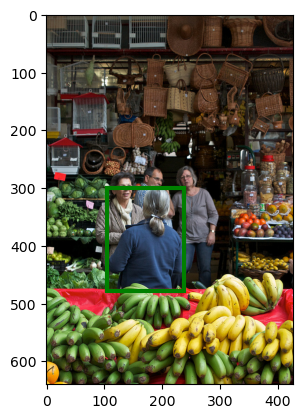

In [9]:
print ('ref_id [%s] (ann_id [%s])' % (ref_id, refer.refToAnn[ref_id]['id']))
# show the segmentation of the referred object
plt.figure()
refer.showRef(ref, seg_box='box')
plt.show()

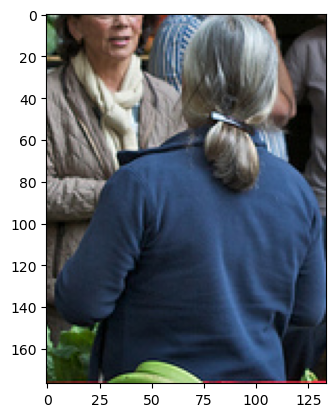

array([[[[ 90, 125,  98],
         [128, 158, 130],
         [192, 216, 184],
         ...,
         [ 50,  39,  33],
         [ 37,  29,  22],
         [ 31,  24,  16]],

        [[ 44,  83,  49],
         [ 67, 107,  72],
         [114, 155, 119],
         ...,
         [ 52,  40,  34],
         [ 44,  34,  27],
         [ 39,  31,  24]],

        [[ 30,  66,  27],
         [ 33,  72,  35],
         [ 48,  90,  58],
         ...,
         [ 51,  40,  33],
         [ 49,  41,  34],
         [ 48,  41,  35]],

        ...,

        [[ 24,  60,  22],
         [ 29,  60,  26],
         [ 33,  62,  33],
         ...,
         [ 21,  10,   3],
         [ 19,  13,   0],
         [ 15,  17,   0]],

        [[ 46,  49,  17],
         [ 49,  54,  24],
         [ 53,  65,  35],
         ...,
         [122,  30,  38],
         [121,  30,  35],
         [120,  30,  32]],

        [[ 99,  39,  18],
         [ 95,  43,  21],
         [ 88,  47,  24],
         ...,
         [255,  61,  90],
        

In [10]:
get_bounded_subimage(ref['image_id'], ref['ann_id'], show=True)

## METER Model

### Config

In [11]:
# ex = Experiment("METER")

def _loss_names(d):
    ret = {
        "itm": 0,
        "mlm": 0,
        "mpp": 0,
        "vqa": 0,
        "vcr": 0,
        "vcr_qar": 0,
        "nlvr2": 0,
        "irtr": 0,
        "contras": 0,
        "snli": 1,
        "ref": 1
    }
    ret.update(d)
    return ret

_config = {  
    "exp_name":"meter",
    "seed" : 0,
    # "datasets" : ["coco", "vg", "sbu", "gcc"],
    # "datasets" : ["coco", "vg"],
    "datasets" : ["coco"],
    "loss_names" : _loss_names({"itm": 1, "mlm": 1}),
    "batch_size" : 1,  # this is a desired batch size; pl trainer will accumulate gradients when per step batch is smaller.

    # Image setting
    "train_transform_keys" : ["imagenet"],
    "val_transform_keys" : ["imagenet"],
    "image_size" : 224,
    "patch_size" : 4,
    "draw_false_image" : 1,
    "image_only" : False,
    "resolution_before" : 224,

    # Text Setting
    "vqav2_label_size" : 3129,
    "max_text_len" : 40,
    "tokenizer" : "google/electra-small-discriminator",
    "vocab_size" : 30522,
    "whole_word_masking" : False, # note that whole_word_masking does not work for RoBERTa
    "mlm_prob" : 0.15,
    "draw_false_text" : 0,

    # Transformer Setting
    "num_top_layer" : 6,
    "input_image_embed_size" : 192,
    "input_text_embed_size" : 256,
    "vit" : "vit_deit_tiny_patch16_224",
    "hidden_size" : 192,
    "num_heads" : 4,
    "num_layers" : 6,
    "mlp_ratio" : 4,
    "drop_rate" : 0.1,

    # Optimizer Setting
    "optim_type" : "adamw",
    "learning_rate" : 1e-5,
    "weight_decay" : 0.01,
    "decay_power" : 1,
    "max_epoch" : 100,
    "max_steps" : 100000,
    "warmup_steps" : 10000,
    "end_lr" : 0,
    "lr_mult_head" : 5,  # multiply lr for downstream heads
    "lr_mult_cross_modal" : 5,  # multiply lr for the cross-modal module

    # Downstream Setting
    "get_recall_metric" : False,
    
    
    "model_type" : "METER",

    # PL Trainer Setting
    "resume_from" : None,
    "fast_dev_run" : False,
    "val_check_interval" : 1.0,
    "test_only" : False,

    # below params varies with the environment
    "data_root" : "/home/claytonfields/nlp/code/vilt/data/arrow",
    "log_dir" : "result",
    "per_gpu_batchsize" : 1,  # you should define this manually with per_gpu_batch_size:#
    "num_gpus" : 1,
    "num_nodes" : 1,
    "load_path" : "",
    "num_workers" : 12,
    "precision" : 32
}

In [12]:
_config = copy.deepcopy(_config)
pl.seed_everything(_config["seed"])

dm = MTDataModule(_config, dist=False)
model = METERTransformerSS(_config)
exp_name = f'{_config["exp_name"]}'
os.makedirs(_config["log_dir"], exist_ok=True)
checkpoint_callback = pl.callbacks.ModelCheckpoint(
    save_top_k=1,
    verbose=True,
    monitor="val/the_metric",
    mode="max",
    save_last=True,
)
logger = pl.loggers.TensorBoardLogger(
    _config["log_dir"],
    name=f'{exp_name}_seed{_config["seed"]}_from_{_config["load_path"].split("/")[-1][:-5]}',
)

lr_callback = pl.callbacks.LearningRateMonitor(logging_interval="step")
callbacks = [checkpoint_callback, lr_callback]

num_gpus = (
    _config["num_gpus"]
    if isinstance(_config["num_gpus"], int)
    else len(_config["num_gpus"])
)

grad_steps = max(_config["batch_size"] // (
    _config["per_gpu_batchsize"] * num_gpus * _config["num_nodes"]
), 1)

max_steps = _config["max_steps"] if _config["max_steps"] is not None else None

trainer = pl.Trainer(
    gpus=_config["num_gpus"],
    num_nodes=_config["num_nodes"],
    precision=_config["precision"],
    benchmark=True,
    deterministic=True,
    max_epochs=_config["max_epoch"] if max_steps is None else 1000,
    max_steps=max_steps,
    callbacks=callbacks,
    logger=logger,
    #prepare_data_per_node=False,
    #replace_sampler_ddp=False,
    accumulate_grad_batches=grad_steps,
    log_every_n_steps=10,
    flush_logs_every_n_steps=10,
    resume_from_checkpoint=_config["resume_from"],
    weights_summary="top",
    fast_dev_run=_config["fast_dev_run"],
    val_check_interval=_config["val_check_interval"],
)

# if not _config["test_only"]:
#     trainer.fit(model, datamodule=dm)
# else:
#     trainer.test(model, datamodule=dm)

Global seed set to 0
Some weights of the model checkpoint at google/electra-small-discriminator were not used when initializing ElectraModel: ['discriminator_predictions.dense_prediction.bias', 'discriminator_predictions.dense_prediction.weight', 'discriminator_predictions.dense.weight', 'discriminator_predictions.dense.bias']
- This IS expected if you are initializing ElectraModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing ElectraModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
GPU available: True, used: True
TPU available: False, using: 0 TPU cores


### Data Module

In [13]:
dm.prepare_data()
dm.setup('fit')

In [14]:
dm.train_dataloader()

In [15]:
dm.train_dataset

In [16]:
# from meter.datasets import CocoCaptionKarpathyDataset

# coco_ds = CocoCaptionKarpathyDataset('home/claytonfields/nlp/code/vilt/data/arrow',['imagenet'],224,
#                                     split='test')
# coco_ds

### Training Loop

In [17]:
epochs = 1
loader = dm.train_dataloader()
optim = AdamW(model.parameters(), lr=1e-4)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [18]:
for i,batch in enumerate(loader):
    output = model(batch)
    if i == 1:
        break
    print(output)

{'text_feats': tensor([[[ 0.9174,  1.8675, -1.1238,  ...,  0.2688, -0.8375,  1.2061],
         [-0.1940,  1.5929,  2.0132,  ..., -0.2873,  0.5163,  0.5869],
         [-0.1628, -0.9818,  0.0962,  ..., -0.2633, -1.0054, -0.8543],
         ...,
         [ 0.3769, -0.5441,  1.0571,  ..., -2.1873, -0.2334,  0.0079],
         [ 0.4685, -0.4521,  1.0232,  ..., -2.1849, -0.3037,  0.2176],
         [ 0.2748, -0.5126,  0.8619,  ..., -1.9551, -0.5254,  0.3826]]],
       grad_fn=<NativeLayerNormBackward0>), 'image_feats': tensor([[[ 0.4689, -1.2019,  1.5307,  ...,  0.6825,  1.4214,  0.7080],
         [ 0.1213, -0.2734,  1.6227,  ...,  0.2200,  0.1612, -0.5886],
         [-0.1928, -0.7198,  1.7069,  ..., -0.0772,  0.0112, -0.2542],
         ...,
         [ 1.0963,  0.3404, -0.4230,  ..., -0.0234,  0.3258,  1.0790],
         [ 0.6585, -0.4882,  1.7964,  ...,  0.7838,  1.1759,  0.3925],
         [ 0.4365, -1.3935,  0.4396,  ...,  0.3008,  0.9442, -0.8425]]],
       grad_fn=<NativeLayerNormBackward0>)

In [19]:
infer_dict = model.infer(batch)
infer_dict

{'text_feats': tensor([[[-0.1588,  1.9203, -1.1546,  ...,  0.2908, -0.5282,  0.5223],
          [-0.1969,  1.3096,  1.1760,  ..., -0.4407,  0.2257,  1.0706],
          [-0.2055, -0.6078,  0.1921,  ..., -0.4889, -1.5782, -0.1034],
          ...,
          [ 0.5040, -0.5066,  0.8054,  ..., -2.3749, -0.0933,  0.1113],
          [ 0.1425, -0.3572,  0.7011,  ..., -2.3430, -0.5314,  0.2146],
          [ 0.3484, -0.2463,  1.0988,  ..., -2.2200, -0.4817,  0.2599]]],
        grad_fn=<NativeLayerNormBackward0>),
 'image_feats': tensor([[[ 0.6942, -1.1865,  1.5145,  ...,  0.5038,  1.4659,  0.6132],
          [-0.0359, -0.1412,  1.5557,  ...,  0.1594,  0.1741, -0.4539],
          [-0.1947, -0.6913,  1.9809,  ...,  0.0856, -0.2215, -0.4062],
          ...,
          [ 1.2244,  0.5208, -0.2500,  ..., -0.0243,  0.2094,  1.1744],
          [ 0.7882, -0.4518,  1.7712,  ...,  0.5968,  1.2423,  0.3185],
          [ 0.4134, -1.5064,  0.3205,  ...,  0.3749,  0.8869, -0.9542]]],
        grad_fn=<NativeLayer

In [23]:
batch

{'img_index': [0],
 'image': [tensor([[[[-1.4158, -1.3130, -1.3644,  ...,  1.8037,  1.7865,  1.7352],
            [-1.3302, -1.3130, -1.3815,  ...,  1.8893,  1.8893,  1.8037],
            [-1.2445, -1.2959, -1.2788,  ...,  1.9578,  1.9578,  1.8379],
            ...,
            [-1.8610, -1.9124, -1.9295,  ...,  1.6838,  1.6667,  1.7180],
            [-1.9295, -1.8610, -1.8953,  ...,  1.6324,  1.7180,  1.7865],
            [-1.9295, -1.8953, -1.8782,  ...,  1.7009,  1.7865,  1.8037]],
  
           [[-1.3880, -1.2829, -1.3179,  ...,  2.1134,  2.0959,  1.9909],
            [-1.3179, -1.2829, -1.3354,  ...,  2.2010,  2.2010,  2.0434],
            [-1.2129, -1.2829, -1.2654,  ...,  2.2710,  2.2710,  2.0784],
            ...,
            [-1.6155, -1.6856, -1.6856,  ...,  1.5007,  1.5707,  1.6583],
            [-1.6856, -1.6155, -1.7031,  ...,  1.5007,  1.6758,  1.7633],
            [-1.7031, -1.6331, -1.7206,  ...,  1.6057,  1.7808,  1.7983]],
  
           [[-1.2641, -1.1944, -1.2119,  .

In [20]:
cls_feats = infer_dict['cls_feats']
cls_feats.shape

torch.Size([1, 384])

In [21]:
model.ref_classifier(cls_feats).argmax()

tensor(21)

## To Do:

Find maximum number of regions in a refcoco image, make this the classifier size



In [22]:
# for epoch in range(epochs):
#     loop = tqdm(loader, leave=True)

#     # set model to training mode
#     model.train()
#     losses = []

#     # iterate over dataset
#     for batch in loop:
#         optim.zero_grad()

#         # copy input to device
#         input_ids = batch['input_ids'].to(device)
#         attention_mask = batch['attention_mask'].to(device)
#         labels = batch['labels'].to(device)

#         # predict
#         outputs = model(input_ids, attention_mask=attention_mask, labels=labels)

#         # update weights
#         loss = outputs.loss
#         loss.backward()

#         optim.step()

#         # output current loss
#         loop.set_description(f'Epoch {epoch}')
#         loop.set_postfix(loss=loss.item())
#         losses.append(loss.item())

#         del input_ids
#         del attention_mask
#         del labels